In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
import warnings
 
warnings.filterwarnings('ignore')

In [ ]:
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "#F7F9FC",
    "axes.facecolor": "#F7F9FC",
})
ACCENT = "#4C72B0"   # primary blue
WARN   = "#DD8452"

df = pd.read_csv('preprocess_1.csv', index_col=0)
 
print("=" * 60)
print(f"  Dataset loaded  →  {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 60)
print(df.dtypes.to_string())
print("\nNull counts:\n", df.isnull().sum()[df.isnull().sum() > 0])
 

  Dataset loaded  →  578 rows × 34 columns
Name                  str
Screen Size       float64
Display               str
NFC                 int64
Battery           float64
antutu_11         float64
clock             float64
Brand                 str
OS_Name               str
OS_Version        float64
Refresh Rate      float64
total_cores       float64
max_freq_ghz      float64
min_freq_ghz      float64
weighted_mean     float64
rear_count        float64
rear_mp_max       float64
rear_f/           float64
rear_ois          float64
rear_telephoto    float64
rear_wide         float64
front_mp          float64
front_f/          float64
Chipset_name          str
Chipset_gen           str
gpu_name              str
gpu_gen               str
PPI               float64
SIM_total           int64
has_eSIM            int64
RAM_min           float64
RAM_max           float64
ROM_min           float64
ROM_max           float64

Null counts:
 Series([], dtype: int64)


1.1 — CORRELATION & MULTICOLLINEARITY ANALYSIS  

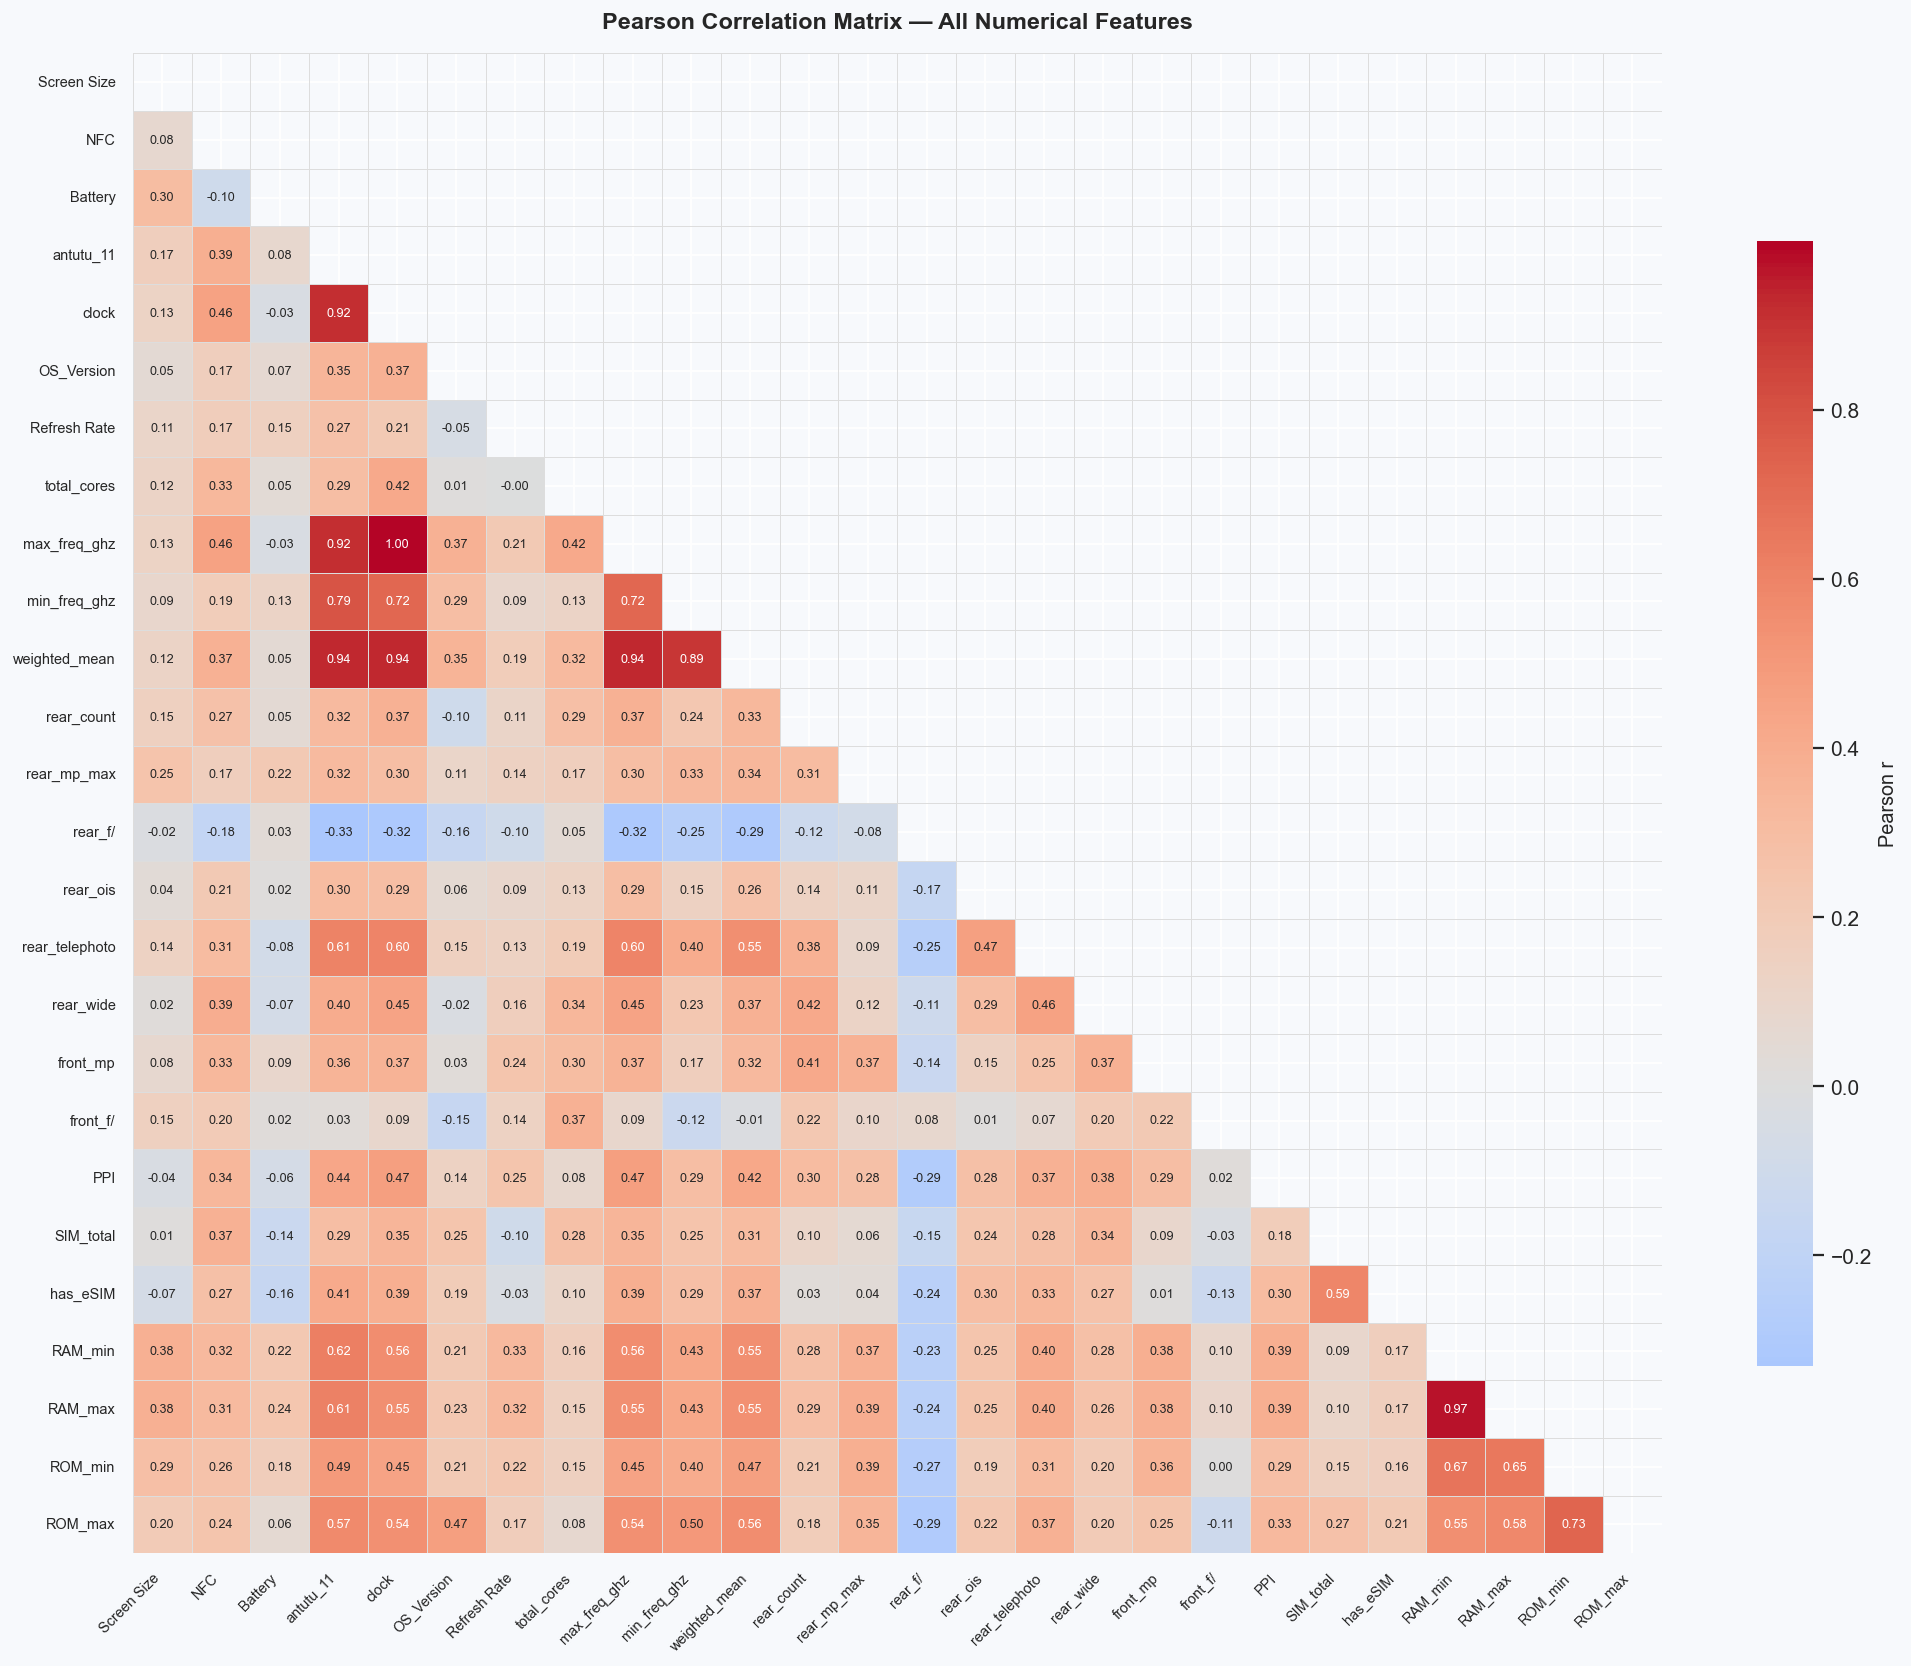

In [ ]:
NUM_COLS = df.select_dtypes(include=np.number).columns.tolist()
# Drop the index column if it sneaked in
NUM_COLS = [c for c in NUM_COLS if c.lower() not in ('unnamed: 0',)]
 
corr_matrix = df[NUM_COLS].corr(method='pearson')
 
# ── 1a. Full heatmap ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))          # upper triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4, linecolor="#DDDDDD",
    annot_kws={"size": 7}, ax=ax,
    cbar_kws={"shrink": 0.75, "label": "Pearson r"}
)
ax.set_title("Pearson Correlation Matrix — All Numerical Features", pad=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
#plt.savefig('1_correlation_heatmap.png', bbox_inches='tight')
plt.show()

In [ ]:
HIGH_THRESH = 0.85
upper_tri = corr_matrix.where(mask)          # keep only upper triangle values
high_corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_A", "level_1": "Feature_B", 0: "r"})
    .query("abs(r) > @HIGH_THRESH and abs(r) < 1")
    .sort_values("r", key=abs, ascending=False)
)

print("Highly Correlated Pairs  (|r| > 0.85)")
if high_corr_pairs.empty:
    print("  None found above threshold.")
else:
    print(high_corr_pairs.to_string(index=False))
print()

Highly Correlated Pairs  (|r| > 0.85)
   Feature_A     Feature_B        r
       clock  max_freq_ghz 1.000000
     RAM_min       RAM_max 0.971453
max_freq_ghz weighted_mean 0.937424
       clock weighted_mean 0.937409
   antutu_11 weighted_mean 0.936225
   antutu_11         clock 0.920566
   antutu_11  max_freq_ghz 0.920547
min_freq_ghz weighted_mean 0.892111



Features max_freg_ghz, RAM_max, weighted_mean, clock will be dropped

In [ ]:
df.drop(columns=['max_freq_ghz', 'RAM_max', 'weighted_mean', 'clock'], inplace=True)

NUM_COLS = [
    c for c in NUM_COLS
    if c not in ('max_freq_ghz', 'RAM_max', 'weighted_mean', 'clock')
]

In [ ]:
NUM_COLS = [
    c for c in NUM_COLS
    if c not in ('max_freq_ghz', 'RAM_max', 'weighted_mean', 'clock')
]

 1.2 DISTRIBUTION & OUTLIER DETECTION  

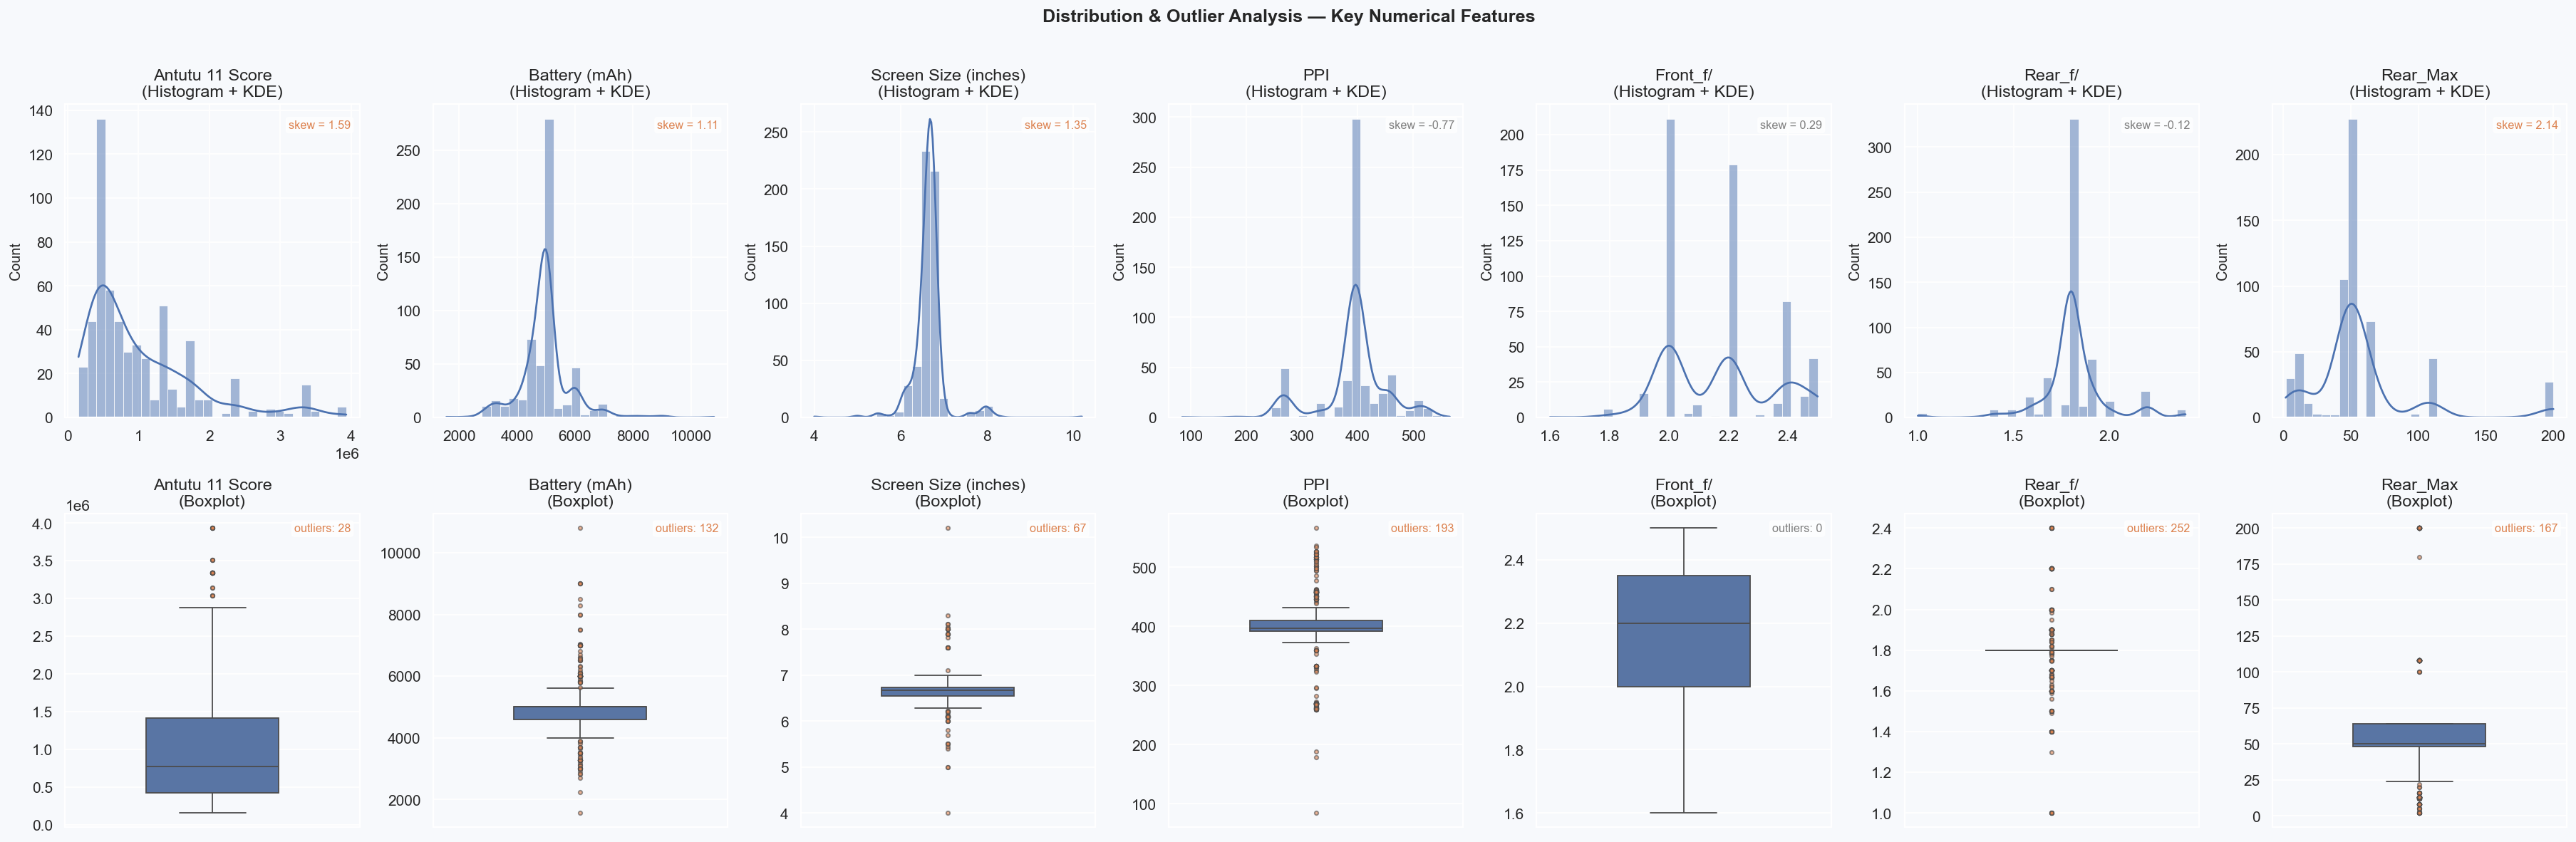

In [ ]:
KEY_COLS  = ['antutu_11', 'Battery', 'Screen Size', 'PPI', 'front_f/', 'rear_f/', 'rear_mp_max']
LABELS    = ['Antutu 11 Score', 'Battery (mAh)', 'Screen Size (inches)', 'PPI', 'Front_f/','Rear_f/', 'Rear_Max']
 
fig, axes = plt.subplots(
    nrows=2,
    ncols=len(KEY_COLS),
    figsize=(4 * len(KEY_COLS), 9)
)
fig.suptitle(
    "Distribution & Outlier Analysis — Key Numerical Features",
    fontsize=14, fontweight='bold', y=1.01
)
 
for i, (col, lbl) in enumerate(zip(KEY_COLS, LABELS)):
    data = df[col].dropna()
 
    # Histogram + KDE
    ax_hist = axes[0, i]
    sns.histplot(data, kde=True, ax=ax_hist, color=ACCENT, bins=30,
                 edgecolor='white', linewidth=0.4)
    ax_hist.set_title(f"{lbl}\n(Histogram + KDE)")
    ax_hist.set_xlabel("")
    skew_val = data.skew()
    ax_hist.text(0.97, 0.95, f"skew = {skew_val:.2f}",
                 transform=ax_hist.transAxes, ha='right', va='top',
                 fontsize=9, color=WARN if abs(skew_val) > 1 else 'grey',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
 
    # Boxplot
    ax_box = axes[1, i]
    sns.boxplot(y=data, ax=ax_box, color=ACCENT, width=0.45,
                flierprops=dict(marker='o', markersize=3,
                                markerfacecolor=WARN, alpha=0.6))
    ax_box.set_title(f"{lbl}\n(Boxplot)")
    ax_box.set_ylabel("")
 
    # Annotate outlier count
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax_box.text(0.97, 0.97, f"outliers: {n_out}",
                transform=ax_box.transAxes, ha='right', va='top',
                fontsize=9, color=WARN if n_out > 10 else 'grey',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
 
plt.tight_layout()
#plt.savefig('2_distribution_outliers.png', bbox_inches='tight')
plt.show()

Do log-transform with Antutu-11, Battery, Screen Size, Rear_max since they are right_skewed

Refresh Rate & OS_Version distribution

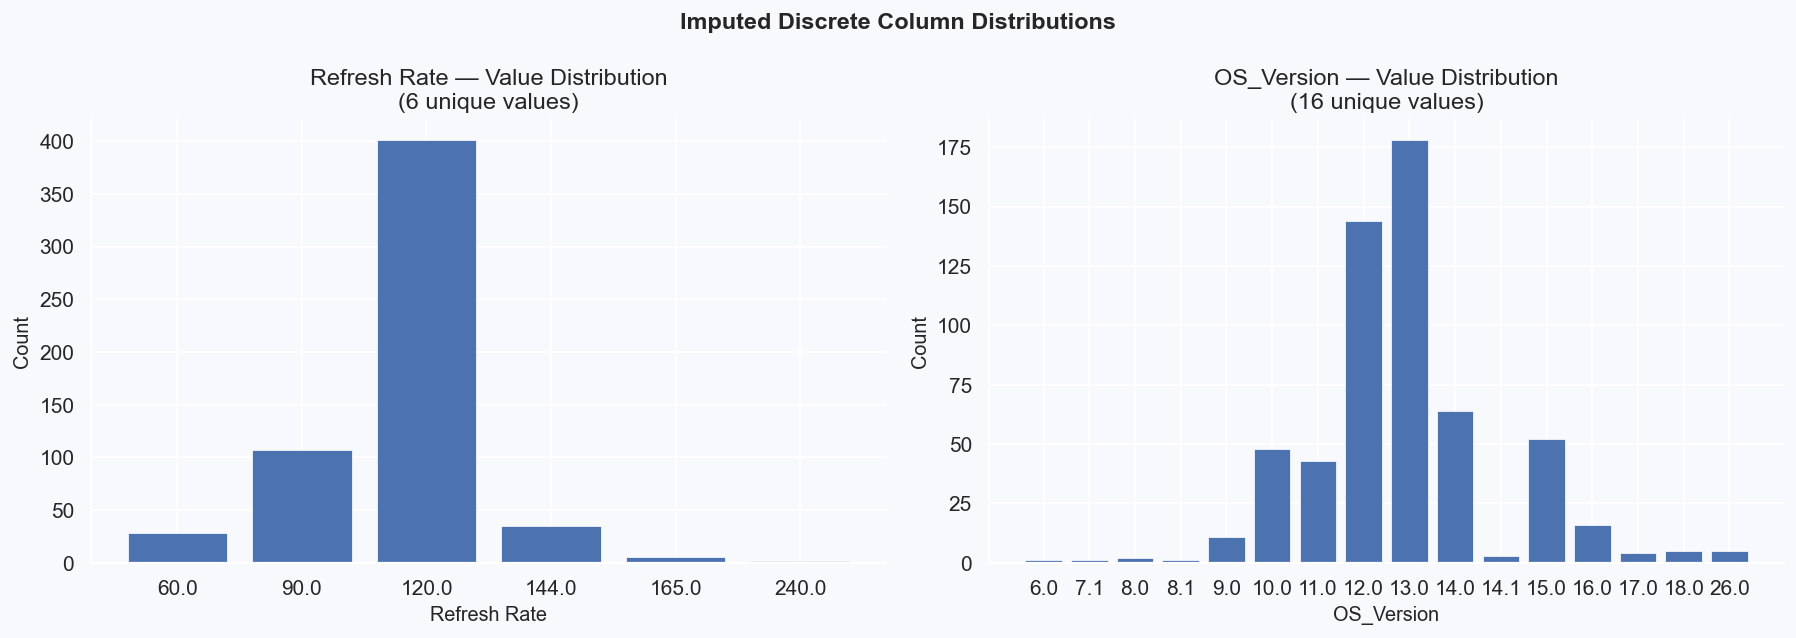

In [ ]:
# Refresh Rate & OS_Version distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Imputed Discrete Column Distributions", fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['Refresh Rate', 'OS_Version']):
    freq = df[col].value_counts().sort_index()
    ax.bar(freq.index.astype(str), freq.values, color=ACCENT, edgecolor='white', linewidth=0.4)
    ax.set_title(f"{col} — Value Distribution\n({df[col].nunique()} unique values)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

RAM & ROM tier distribution

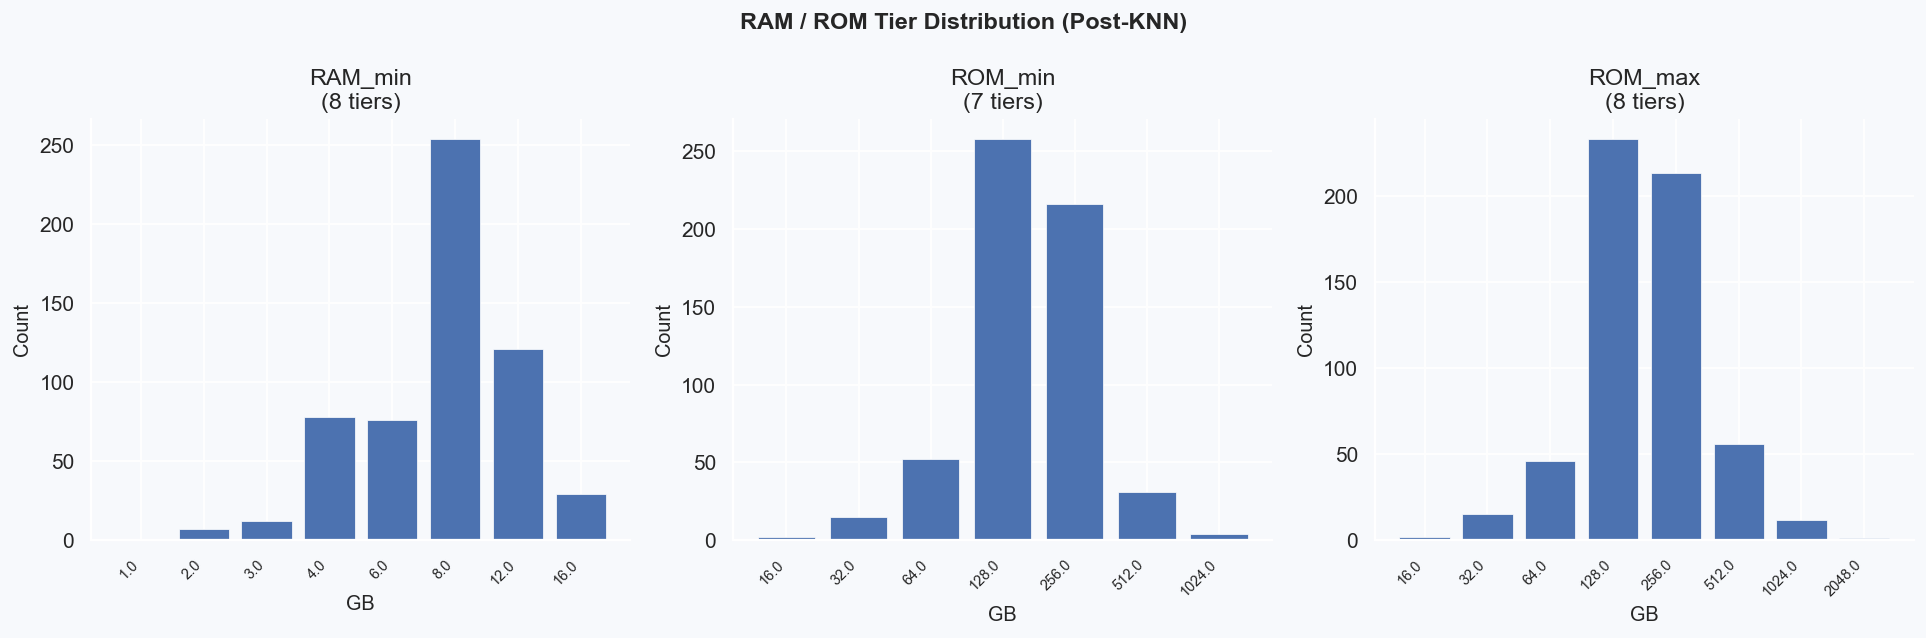

In [ ]:

ram_rom_cols = ['RAM_min', 'ROM_min', 'ROM_max']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("RAM / ROM Tier Distribution (Post-KNN)", fontsize=13, fontweight='bold')

for ax, col in zip(axes, ram_rom_cols):
    freq = df[col].value_counts().sort_index()
    ax.bar(freq.index.astype(str), freq.values, color=ACCENT, edgecolor='white', linewidth=0.4)
    ax.set_title(f"{col}\n({df[col].nunique()} tiers)")
    ax.set_xlabel("GB")
    ax.set_ylabel("Count")
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

1.3 DOMAIN ANOMALY VALIDATION

In [ ]:
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "#F7F9FC",
    "axes.facecolor": "#F7F9FC",
})
ACCENT = "#4C72B0"
WARN   = "#DD8452"
FLAG   = "#D62728"

  Suspect Imputation Report
  Total flagged rows     : 4 / 578 (0.7%)
  Rule — Legacy Battery  : 1 rows
  Rule — High Refresh    : 3 rows

  Flagged phones:
                Name  Battery  antutu_11  Refresh Rate  Brand
0    apple iphone 5s   1560.0   419670.0         120.0  apple
443          vivo v7   3000.0   176718.0         120.0   vivo
484         vivo y71   3360.0   180934.0         120.0   vivo
487         vivo y95   4030.0   193115.0         120.0   vivo



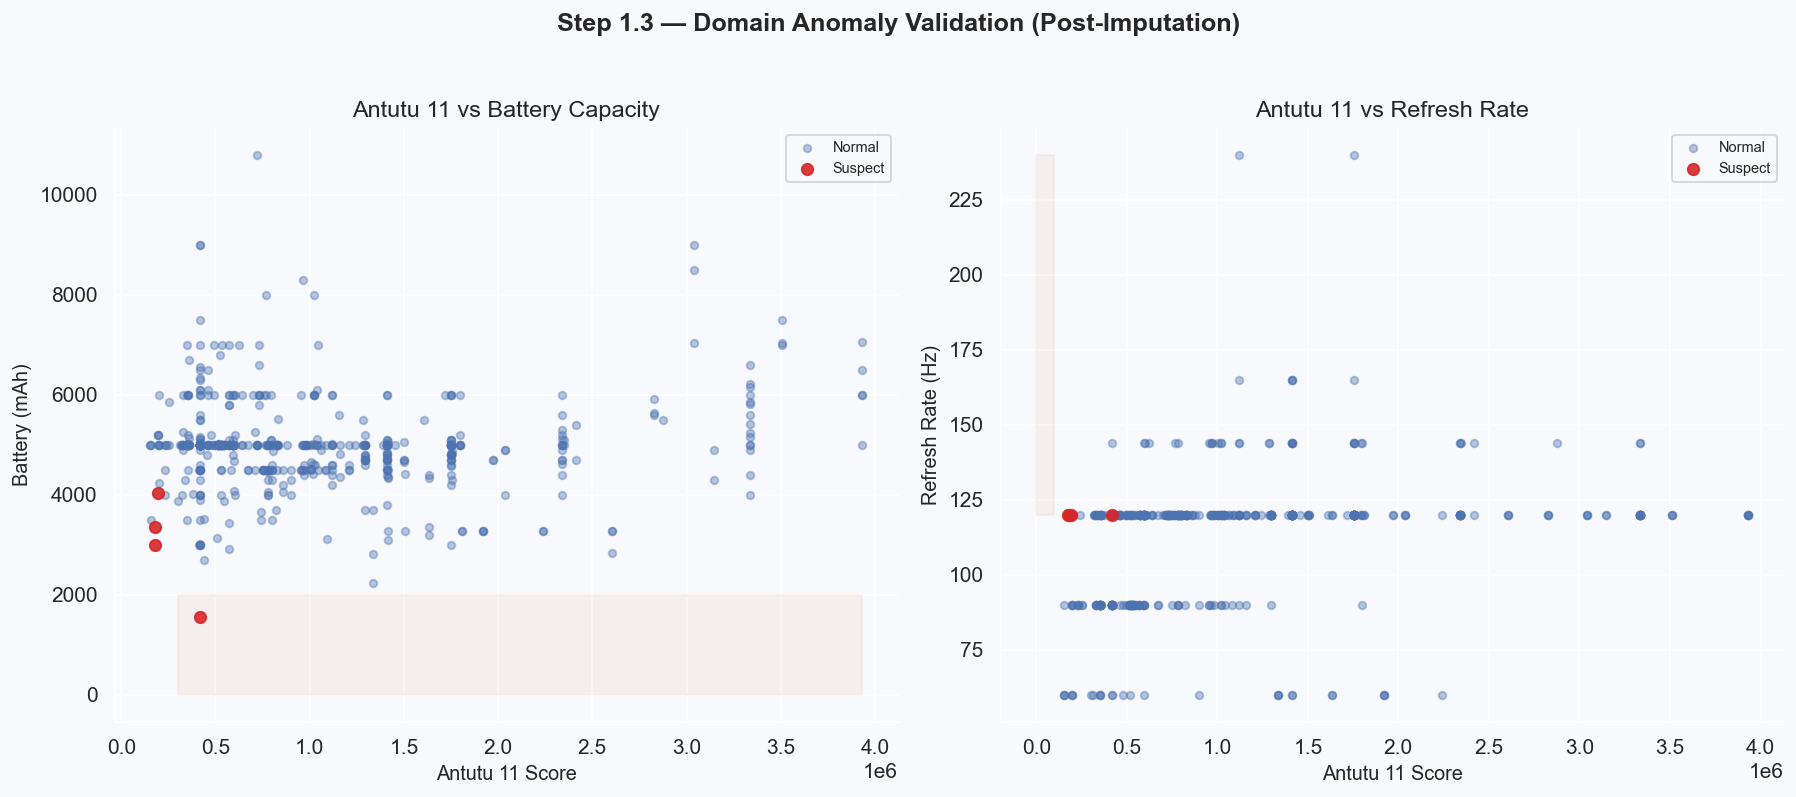

In [ ]:
rule_legacy_battery  = (df['Battery']      <  2000) & (df['antutu_11']   >  300_000)
rule_high_refresh    = (df['Refresh Rate'] >= 120)   & (df['antutu_11']   <  200_000)
 
df['suspect_imputation'] = (rule_legacy_battery | rule_high_refresh).astype(int)
 
 
# ── Flagging Report ───────────────────────────────────────────────────────────
total_flagged = df['suspect_imputation'].sum()
print("=" * 60)
print(f"  Suspect Imputation Report")
print("=" * 60)
print(f"  Total flagged rows     : {total_flagged} / {len(df)} ({total_flagged/len(df)*100:.1f}%)")
print(f"  Rule — Legacy Battery  : {rule_legacy_battery.sum()} rows")
print(f"  Rule — High Refresh    : {rule_high_refresh.sum()} rows")
print()
 
if total_flagged > 0:
    print("  Flagged phones:")
    print(df[df['suspect_imputation'] == 1][
        ['Name', 'Battery', 'antutu_11', 'Refresh Rate', 'Brand']
    ].to_string(index=True))

print()
 
 
# ── Scatter Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Step 1.3 — Domain Anomaly Validation (Post-Imputation)",
             fontsize=14, fontweight='bold', y=1.02)
 
normal  = df[df['suspect_imputation'] == 0]
flagged = df[df['suspect_imputation'] == 1]
 
plot_configs = [
    {
        'ax'   : axes[0],
        'x'    : 'antutu_11',
        'y'    : 'Battery',
        'title': 'Antutu 11 vs Battery Capacity',
        # Danger zone: modern score on legacy battery
        'rect' : dict(x=300_000, y=0, w=df['antutu_11'].max()-300_000, h=2000),
        'xlabel': 'Antutu 11 Score',
        'ylabel': 'Battery (mAh)',
    },
    {
        'ax'   : axes[1],
        'x'    : 'antutu_11',
        'y'    : 'Refresh Rate',
        'title': 'Antutu 11 vs Refresh Rate',
        # Danger zone: high refresh on budget chip
        'rect' : dict(x=0, y=120, w=100_000, h=df['Refresh Rate'].max()-120),
        'xlabel': 'Antutu 11 Score',
        'ylabel': 'Refresh Rate (Hz)',
    },
]
 
for cfg in plot_configs:
    ax = cfg['ax']
 
    ax.scatter(normal[cfg['x']], normal[cfg['y']],
               alpha=0.4, s=18, color=ACCENT, label='Normal')
 
    # Flagged points plotted on top in red so they're always visible
    if len(flagged) > 0:
        ax.scatter(flagged[cfg['x']], flagged[cfg['y']],
                   alpha=0.9, s=40, color=FLAG, zorder=5, label='Suspect')
 
    r = cfg['rect']
    ax.add_patch(mpatches.Rectangle(
        (r['x'], r['y']), r['w'], r['h'],
        linewidth=1.2, edgecolor=WARN, facecolor=WARN, alpha=0.08, zorder=2
    ))
 
    ax.set_title(cfg['title'])
    ax.set_xlabel(cfg['xlabel'])
    ax.set_ylabel(cfg['ylabel'])
    ax.legend(fontsize=8)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
 
plt.tight_layout()
#plt.savefig('1_3_anomaly_validation.png', bbox_inches='tight')
plt.show()
df.drop(columns=['suspect_imputation'], inplace=True)
 

1.4 PCA SCREE PLOT

Drop SIM_total, has_eSIM, NFC, rear_ois, rear_telephoto, rear_wide. Because binary columns with near-zero or near-one distributions contribute negligible variance to PCA and can distort component loadings. 

  PCA input shape: (578, 16)  (16 features)


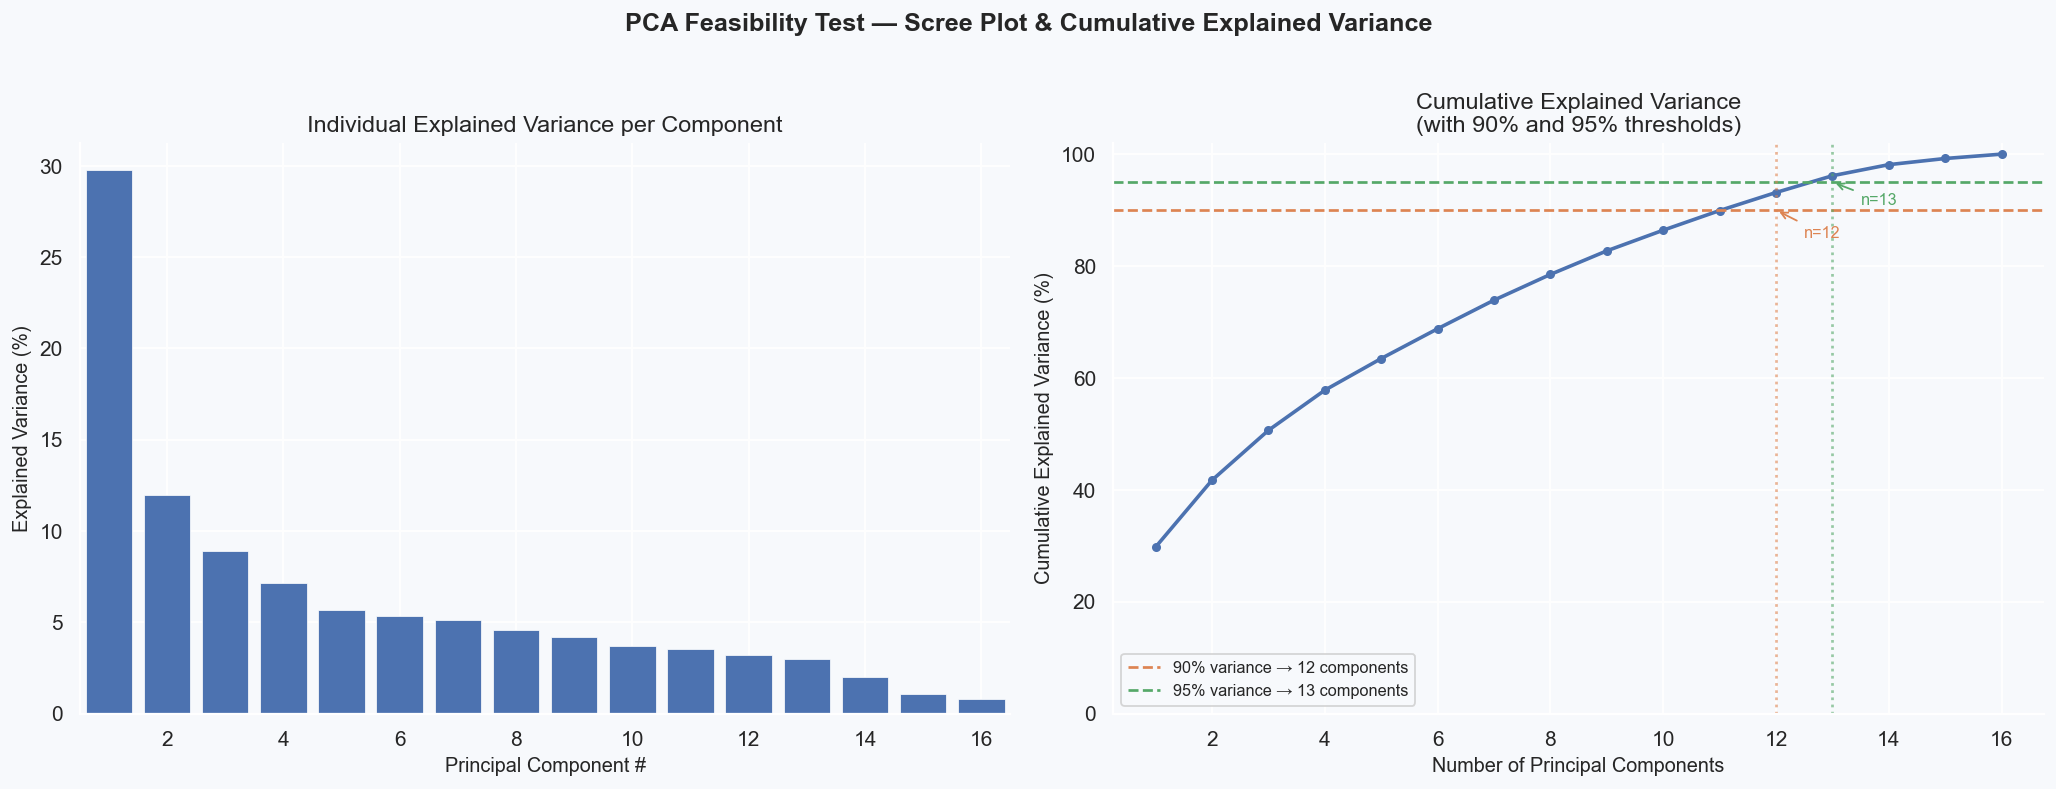

In [ ]:
pca_cols = [c for c in NUM_COLS
            if df[c].dropna().std() > 0 and c not in ('SIM_total', 'has_eSIM',
                                                        'NFC', 'rear_ois',
                                                        'rear_telephoto', 'rear_wide')]
pca_df = df[pca_cols].dropna()
print(f"  PCA input shape: {pca_df.shape}  ({pca_df.shape[1]} features)")
 
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(pca_df)
 
pca_full   = PCA()
pca_full.fit(X_scaled)
 
cum_var    = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_comp     = np.arange(1, len(cum_var) + 1)
 
# Threshold crossings
n_90 = np.searchsorted(cum_var, 90) + 1
n_95 = np.searchsorted(cum_var, 95) + 1
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA Feasibility Test — Scree Plot & Cumulative Explained Variance",
             fontsize=14, fontweight='bold', y=1.01)
 
# ── 5a. Individual explained variance (scree) ─────────────────────────────────
ax1.bar(n_comp, pca_full.explained_variance_ratio_ * 100,
        color=ACCENT, edgecolor='white', linewidth=0.4)
ax1.set_title("Individual Explained Variance per Component")
ax1.set_xlabel("Principal Component #")
ax1.set_ylabel("Explained Variance (%)")
ax1.set_xlim(0.5, min(len(n_comp) + 0.5, 25))
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
 
# ── 5b. Cumulative explained variance ────────────────────────────────────────
ax2.plot(n_comp, cum_var, 'o-', color=ACCENT, markersize=4, linewidth=2)
ax2.axhline(90, color=WARN,    linestyle='--', linewidth=1.5,
            label=f"90% variance → {n_90} components")
ax2.axhline(95, color='#55A868', linestyle='--', linewidth=1.5,
            label=f"95% variance → {n_95} components")
ax2.axvline(n_90, color=WARN,    linestyle=':', alpha=0.6)
ax2.axvline(n_95, color='#55A868', linestyle=':', alpha=0.6)
 
ax2.annotate(f"n={n_90}", xy=(n_90, 90), xytext=(n_90 + 0.5, 85),
             arrowprops=dict(arrowstyle='->', color=WARN), color=WARN, fontsize=9)
ax2.annotate(f"n={n_95}", xy=(n_95, 95), xytext=(n_95 + 0.5, 91),
             arrowprops=dict(arrowstyle='->', color='#55A868'),
             color='#55A868', fontsize=9)
 
ax2.set_title("Cumulative Explained Variance\n(with 90% and 95% thresholds)")
ax2.set_xlabel("Number of Principal Components")
ax2.set_ylabel("Cumulative Explained Variance (%)")
ax2.set_ylim(0, 102)
ax2.legend(fontsize=9)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
 
plt.tight_layout()
#plt.savefig('5_pca_scree.png', bbox_inches='tight')
plt.show()

In [ ]:
print(f"\n  → 90% variance reached at {n_90} components")
print(f"  → 95% variance reached at {n_95} components")
print(f"  → Total features fed to PCA: {pca_df.shape[1]}")
reduction_90 = round((1 - n_90 / pca_df.shape[1]) * 100, 1)
print(f"  → Dimensionality reduction at 90% threshold: {reduction_90}%\n")


  → 90% variance reached at 12 components
  → 95% variance reached at 13 components
  → Total features fed to PCA: 16
  → Dimensionality reduction at 90% threshold: 25.0%



-> Không nên thực hiên PCA với dataset này

2.1 CARDINALITY INSPECTION

  Step 2.1 — Cardinality & Rare Label Inspection
      Column  Unique Labels  Rare (<3) Rare % Top-5 Coverage                                 Top 5 Labels
Chipset_name              8          0   0.0%          93.8%   Snapdragon, MediaTek, Other, Exynos, Apple
 Chipset_gen             17         81 476.5%          29.9% Unknown, 8 Gen 2, 8 Plus Gen 1, 695, 8 Gen 1
    gpu_name              7          1  14.3%          99.1%    Adreno, Mali, PowerVR, Apple GPU, Xclipse
     gpu_gen             22         21  95.5%          41.9%                   GT7600, G57, 730, 740, G52
       Brand             19         13  68.4%          59.9%           samsung, xiaomi, vivo, oppo, honor
     OS_Name              2          0   0.0%         100.0%                                 Android, iOS
     Display              5          0   0.0%         100.0%            AMOLED, IPS LCD, OLED, Other, LCD



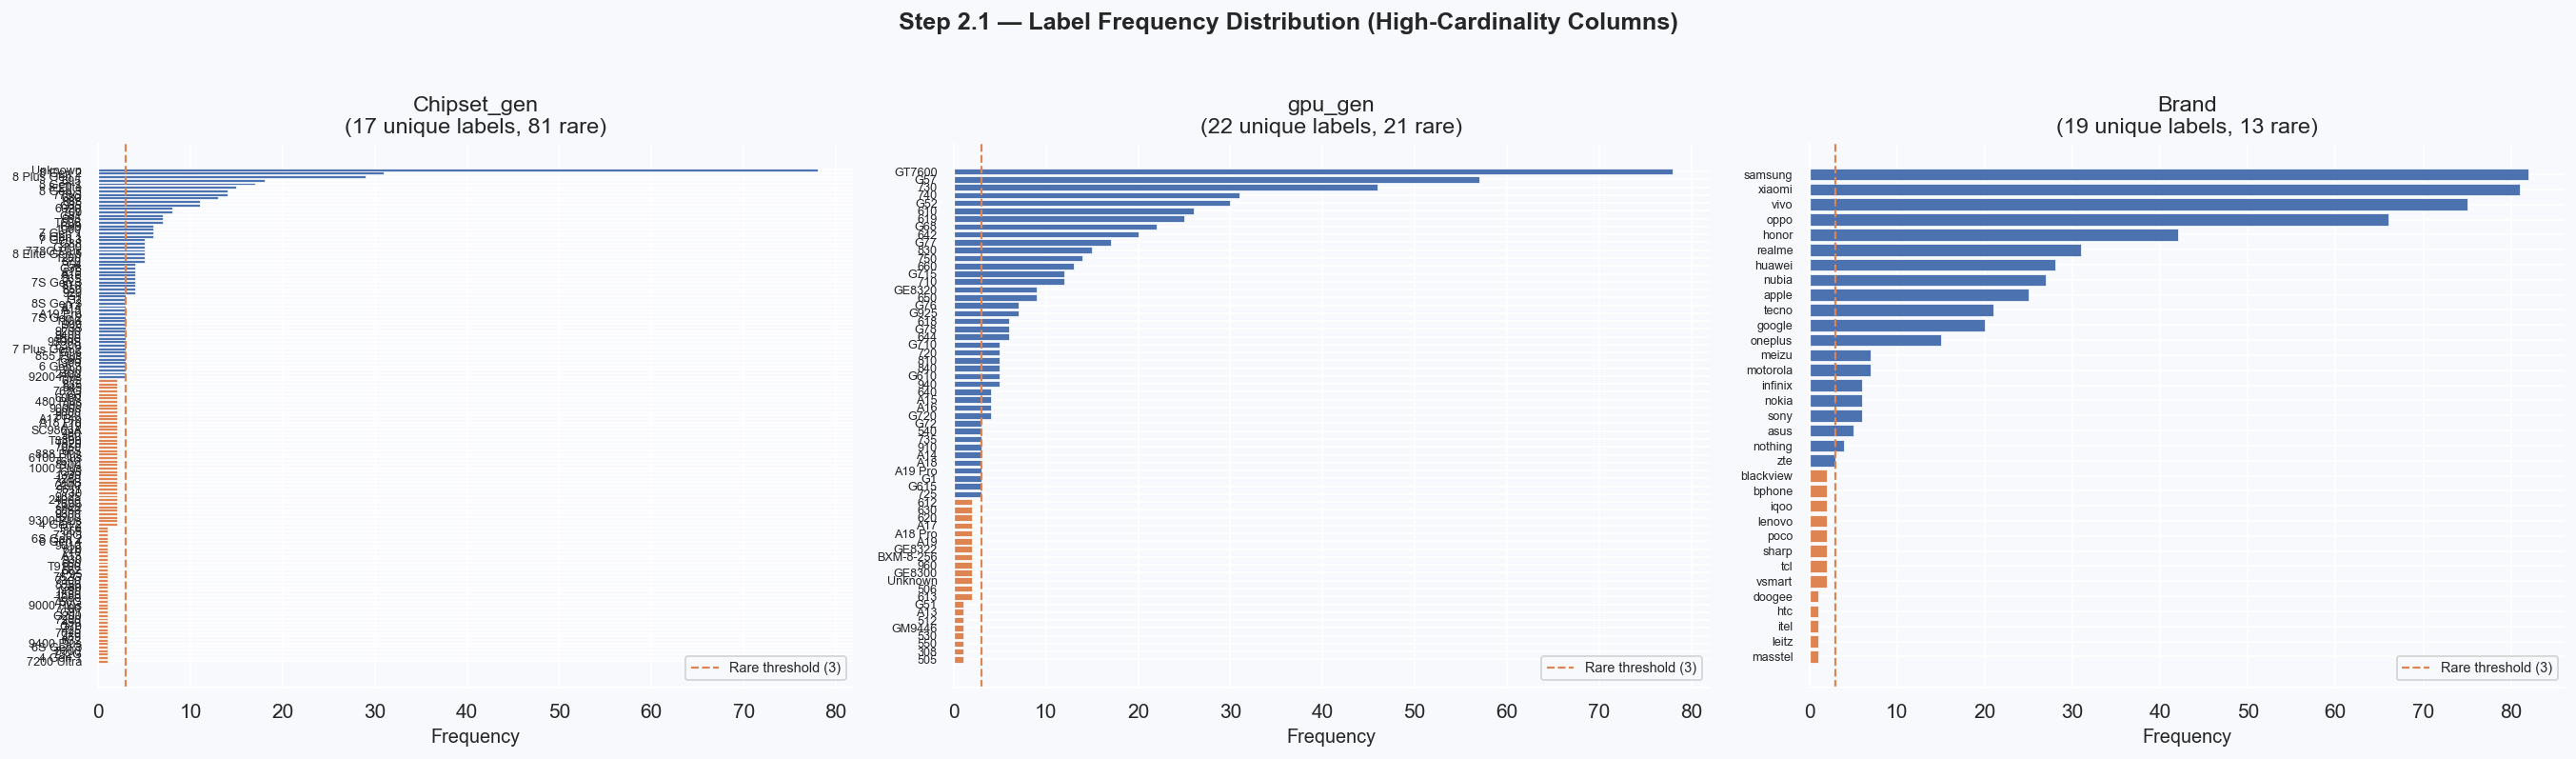

  Rare Labels (< 3 occurrences) per Column:
----------------------------------------------------------------------

  Chipset_gen (81 rare labels):
Chipset_gen
675           2
835           2
845           2
765G          2
G3            2
6080          2
480 Plus      2
980           2
9000s         2
9000          2
8020          2
A17 Pro       2
A18 Pro       2
A19           2
SC9863A       2
480           2
460           2
T8300         2
T820          2
7050          2
665           2
888 Plus      2
6100 Plus     2
T612          2
8100          2
1000 Plus     2
G35           2
1330          2
1280          2
720G          2
2100          2
9611          2
730           2
9825          2
2400e         2
2600          2
A22           2
8050          2
9300          2
8200          2
9300 Plus     2
4 Gen 2       2
P70           1
855           1
730G          1
6S Gen 2      1
6 Gen 4       1
9010          1
820           1
710           1
A13           1
930           1
660     

In [ ]:
CAT_COLS = ['Chipset_name', 'Chipset_gen', 'gpu_name', 'gpu_gen', 'Brand', 'OS_Name', 'Display']
RARE_THRESHOLD = 3
 
 
# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 70)
print("  Step 2.1 — Cardinality & Rare Label Inspection")
print("=" * 70)
 
summary = []
for col in CAT_COLS:
    freq        = df[col].value_counts()
    n_unique    = freq.nunique()
    n_rare      = (freq < RARE_THRESHOLD).sum()
    rare_pct    = n_rare / n_unique * 100
    top5        = freq.head(5).index.tolist()
    top5_cov    = freq.head(5).sum() / len(df) * 100
 
    summary.append({
        'Column'        : col,
        'Unique Labels' : n_unique,
        'Rare (<3)'     : n_rare,
        'Rare %'        : f"{rare_pct:.1f}%",
        'Top-5 Coverage': f"{top5_cov:.1f}%",
        'Top 5 Labels'  : ', '.join(str(x) for x in top5),
    })
 
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
print()
 
 
# ── Per-Column Frequency Bar Charts ──────────────────────────────────────────
# Only plot high-cardinality columns — low cardinality ones are readable in the table
high_card = [col for col in CAT_COLS
             if df[col].nunique() > 10]
 
fig, axes = plt.subplots(1, len(high_card), figsize=(7 * len(high_card), 6))
if len(high_card) == 1:
    axes = [axes]
 
fig.suptitle("Step 2.1 — Label Frequency Distribution (High-Cardinality Columns)",
             fontsize=14, fontweight='bold', y=1.02)
 
for ax, col in zip(axes, high_card):
    freq = df[col].value_counts()
 
    # Color rare labels orange so they're immediately identifiable
    colors = [WARN if v < RARE_THRESHOLD else ACCENT for v in freq.values]
 
    ax.barh(freq.index[::-1], freq.values[::-1],
            color=colors[::-1], edgecolor='white', linewidth=0.4)
    ax.set_title(f"{col}\n({freq.nunique()} unique labels, "
                 f"{(freq < RARE_THRESHOLD).sum()} rare)")
    ax.set_xlabel("Frequency")
    ax.tick_params(axis='y', labelsize=7)
 
    # Rare threshold reference line
    ax.axvline(RARE_THRESHOLD, color=WARN, linestyle='--',
               linewidth=1.2, label=f'Rare threshold ({RARE_THRESHOLD})')
    ax.legend(fontsize=8)
 
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
 
plt.tight_layout()
#plt.savefig('2_1_cardinality.png', bbox_inches='tight')
plt.show()
 
 
# ── Rare Label Detail ─────────────────────────────────────────────────────────
# Print exact rare labels per column so we know what goes into 'Other'
print("  Rare Labels (< 3 occurrences) per Column:")
print("-" * 70)
for col in CAT_COLS:
    freq      = df[col].value_counts()
    rare_vals = freq[freq < RARE_THRESHOLD]
    if len(rare_vals) > 0:
        print(f"\n  {col} ({len(rare_vals)} rare labels):")
        print(rare_vals.to_string())
print()
 

2.2 CROSS-TABULATION CONSISTENCY 

  Crosstab A — Brand × OS_Name
OS_Name    Android  iOS
Brand                  
apple            0   25
asus             5    0
blackview        2    0
bphone           2    0
doogee           1    0
google          20    0
honor           42    0
htc              1    0
huawei          28    0
infinix          6    0
iqoo             2    0
itel             1    0
leitz            1    0
lenovo           2    0
masstel          1    0
meizu            7    0
motorola         7    0
nokia            6    0
nothing          4    0
nubia           27    0
oneplus         15    0
oppo            66    0
poco             2    0
realme          31    0
samsung         82    0
sharp            2    0
sony             6    0
tcl              2    0
tecno           21    0
vivo            75    0
vsmart           2    0
xiaomi          81    0
zte              3    0

  Violations:
  Apple → Android          : 0 rows
  Non-Apple → iOS          : 0 rows
  Total                    : 0 violations


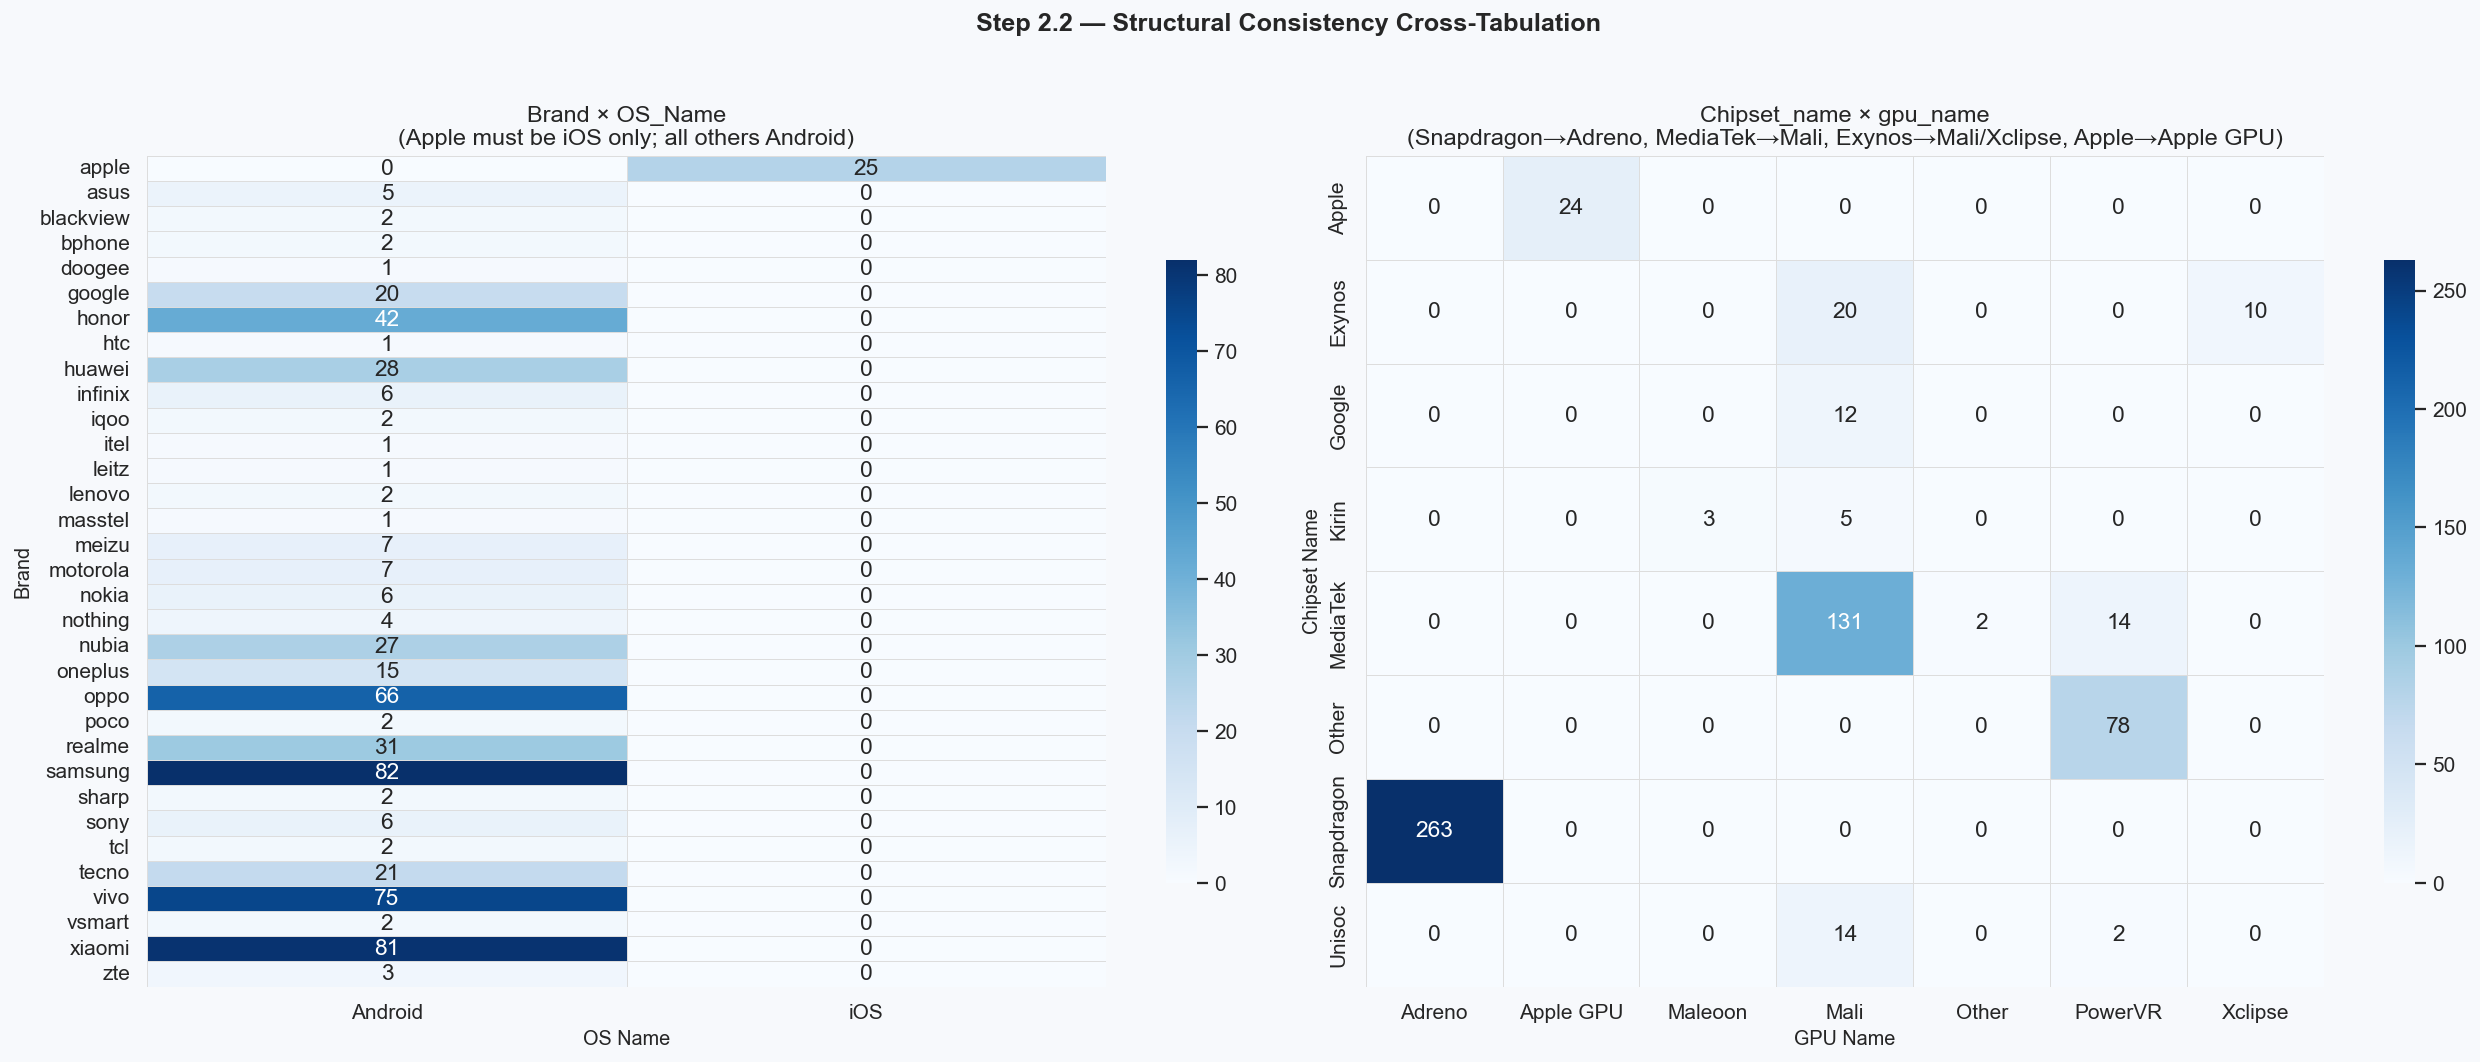

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Step 2.2 — Structural Consistency Cross-Tabulation",
             fontsize=14, fontweight='bold', y=1.02)
 
 
# ── Crosstab A: Brand × OS_Name ───────────────────────────────────────────────
ct_os = pd.crosstab(df['Brand'], df['OS_Name'])
 
sns.heatmap(ct_os, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='#DDDDDD',
            ax=axes[0], cbar_kws={'shrink': 0.75})
axes[0].set_title("Brand × OS_Name\n(Apple must be iOS only; all others Android)")
axes[0].set_xlabel("OS Name")
axes[0].set_ylabel("Brand")
 
# Violations: apple → Android, or non-apple → iOS
apple_android = ct_os.loc['apple', 'Android'] if 'Android' in ct_os.columns else 0
non_apple_ios = ct_os.drop(index='apple')['iOS'].sum() if 'iOS' in ct_os.columns else 0
 
print("=" * 60)
print("  Crosstab A — Brand × OS_Name")
print("=" * 60)
print(ct_os.to_string())
print(f"\n  Violations:")
print(f"  Apple → Android          : {apple_android} rows")
print(f"  Non-Apple → iOS          : {non_apple_ios} rows")
print(f"  Total                    : {apple_android + non_apple_ios} violations\n")
 
 
# ── Crosstab B: Chipset_name × gpu_name ──────────────────────────────────────
ct_gpu = pd.crosstab(df['Chipset_name'], df['gpu_name'])
 
sns.heatmap(ct_gpu, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='#DDDDDD',
            ax=axes[1], cbar_kws={'shrink': 0.75})
axes[1].set_title("Chipset_name × gpu_name\n(Snapdragon→Adreno, MediaTek→Mali, Exynos→Mali/Xclipse, Apple→Apple GPU)")
axes[1].set_xlabel("GPU Name")
axes[1].set_ylabel("Chipset Name")
 
# Known valid pairings — violations are anything outside these
VALID_PAIRS = {
    'Snapdragon' : ['Adreno'],
    'MediaTek'   : ['Mali', 'Immortalis'],
    'Exynos'     : ['Mali', 'Xclipse'],
    'Apple'      : ['Apple GPU'],
    'Google'     : ['Mali'],
    'Kirin'      : ['Mali'],
    'Unisoc'     : ['Mali']
}
 
print("=" * 60)
print("  Crosstab B — Chipset_name × gpu_name")
print("=" * 60)
print(ct_gpu.to_string())
print(f"\n  Violations (invalid chipset-GPU pairings):")
 
total_violations = 0
for chipset, valid_gpus in VALID_PAIRS.items():
    if chipset not in ct_gpu.index:
        continue
    row = ct_gpu.loc[chipset]
    # Any GPU column that is not in the valid list and has count > 0
    invalid = row[~row.index.isin(valid_gpus) & (row > 0)]
    if len(invalid) > 0:
        for gpu, count in invalid.items():
            print(f"  {chipset} → {gpu}: {count} rows")
            total_violations += count
 
if total_violations == 0:
    print("  None found — all chipset-GPU pairings are valid.")
print(f"\n  Total violations: {total_violations}\n")
 
 
plt.tight_layout()
#plt.savefig('2_2_crosstab.png', bbox_inches='tight')
plt.show()
 

2.3 BRAND SEGMENT & MARKET PROFILING 

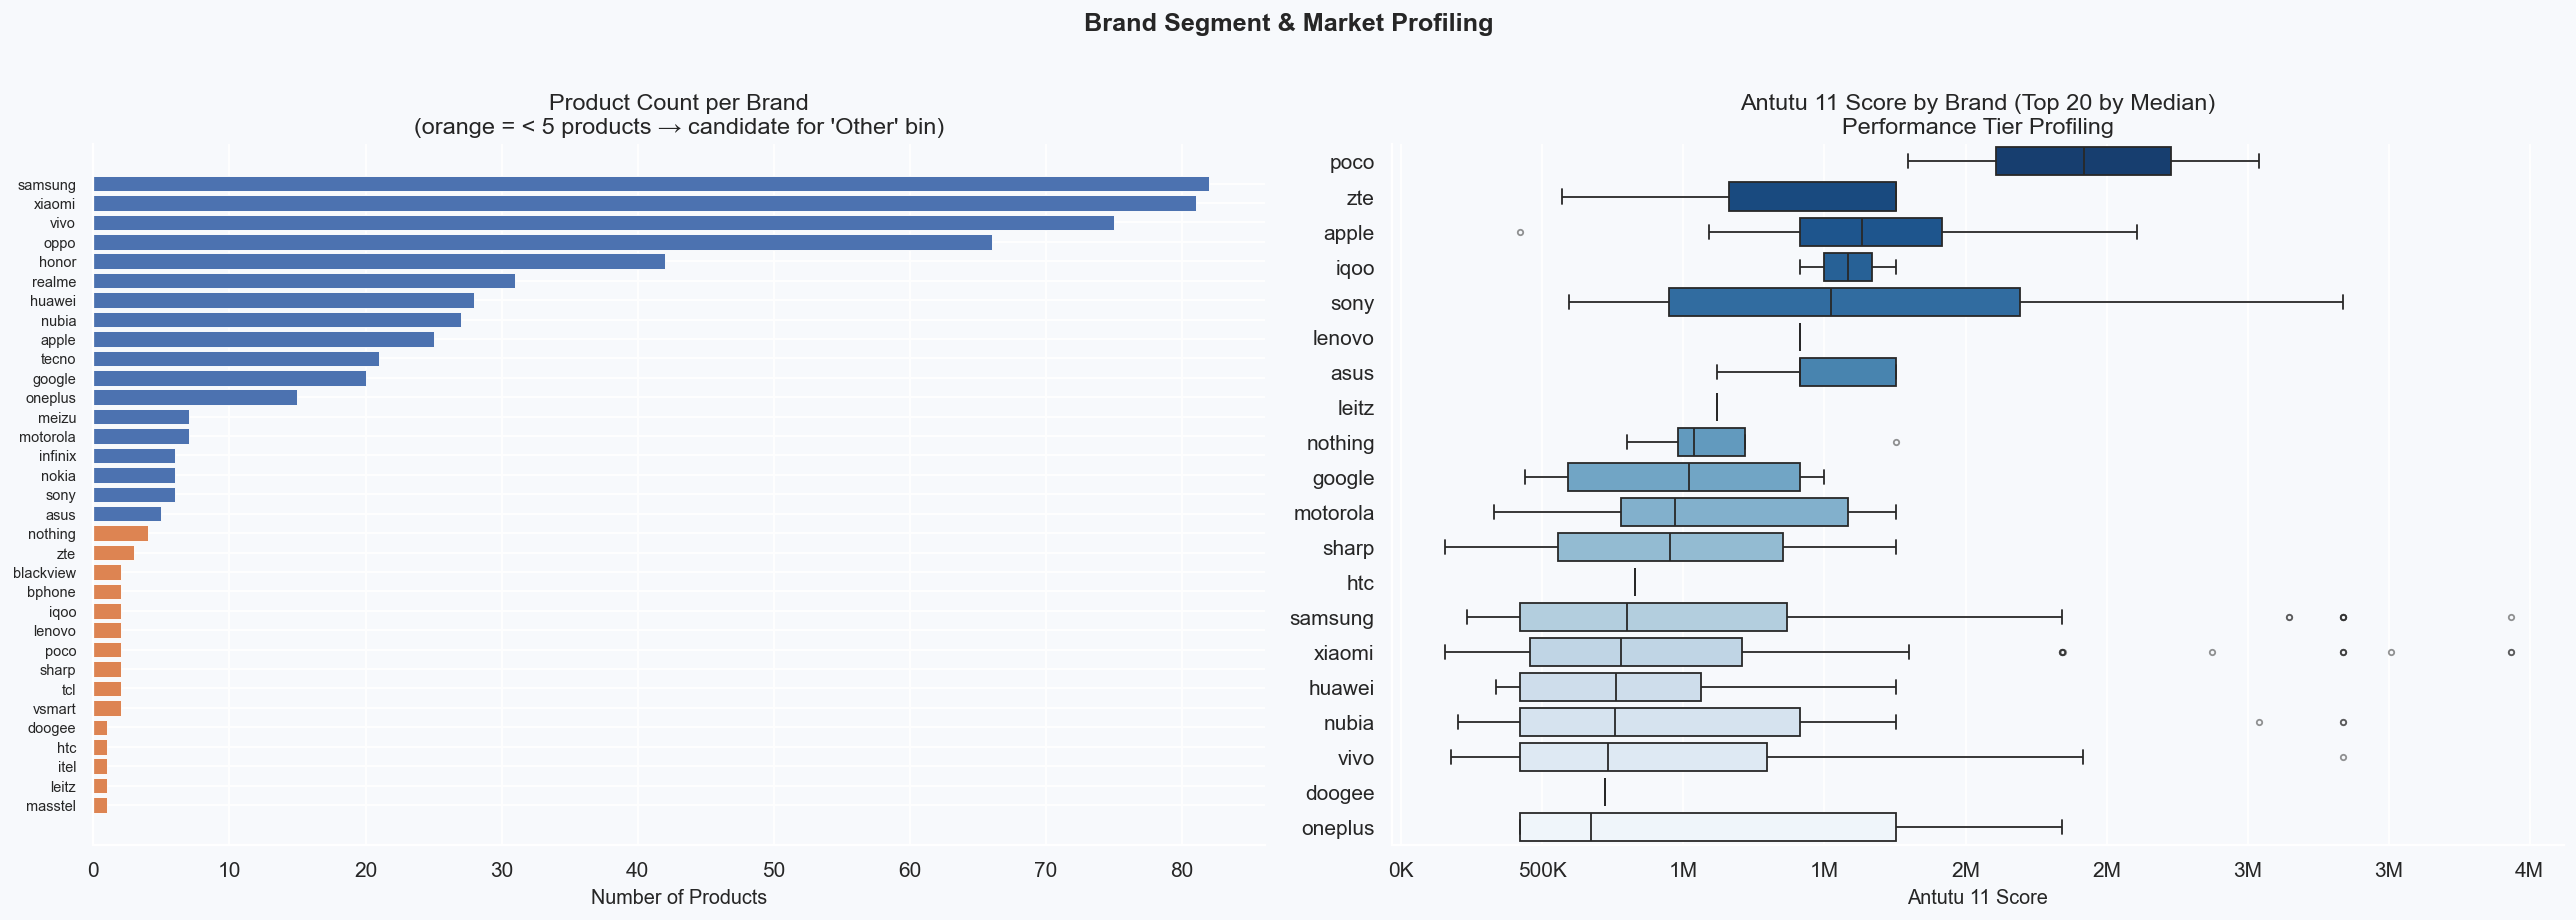

In [ ]:
brand_counts = df['Brand'].value_counts()
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Brand Segment & Market Profiling", fontsize=14,
             fontweight='bold', y=1.01)
 
# ── 3a. Count plot ────────────────────────────────────────────────────────────
brand_order = brand_counts.index.tolist()
bar_colors  = [WARN if brand_counts[b] < 5 else ACCENT for b in brand_order]
 
ax1.barh(brand_order[::-1], brand_counts[brand_order[::-1]],
         color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
ax1.set_xlabel("Number of Products")
ax1.set_title("Product Count per Brand\n(orange = < 5 products → candidate for 'Other' bin)")
ax1.tick_params(axis='y', labelsize=8)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
 
# ── 3b. Brand × Antutu boxplot ────────────────────────────────────────────────
brand_median = df.groupby('Brand')['antutu_11'].median().sort_values(ascending=False)
top_brands   = brand_median.index[:20]          # top-20 by median score
 
plot_df = df[df['Brand'].isin(top_brands)].copy()
plot_df['Brand'] = pd.Categorical(plot_df['Brand'],
                                   categories=brand_median.index, ordered=True)
sns.boxplot(data=plot_df, x='antutu_11', y='Brand',
            order=top_brands, ax=ax2, palette='Blues_r',
            flierprops=dict(marker='o', markersize=3, alpha=0.5))
ax2.set_title("Antutu 11 Score by Brand (Top 20 by Median)\nPerformance Tier Profiling")
ax2.set_xlabel("Antutu 11 Score")
ax2.set_ylabel("")
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'{int(x/1e6)}M' if x >= 1e6 else f'{int(x/1e3)}K'))
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
 
plt.tight_layout()
#plt.savefig('/mnt/user-data/outputs/3_brand_profiling.png', bbox_inches='tight')
plt.show()

3.1 FEATURE ENGINEERING: NEED-TAG MAPPING


  Need-Tag Distribution:
Gaming_Need           221
HighRes_Need          189
Performance_Need      183
Multitask_Need        150
Battery_Need           79
Large_Display_Need     76
Photography_Need       57


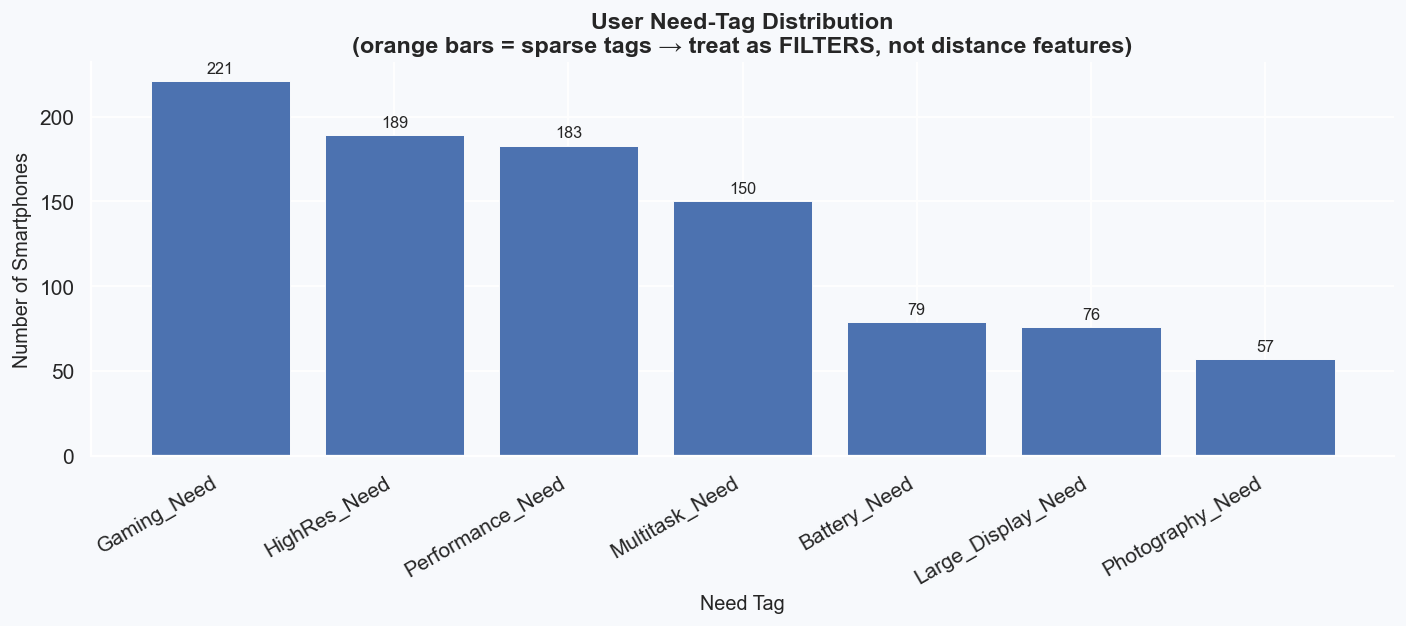

In [ ]:
df_tags = df.copy()
 
df_tags['Gaming_Need']       = ((df_tags['antutu_11']    >  900_000) &
                                 (df_tags['Refresh Rate'] >=  120)).astype(int)
 
df_tags['Battery_Need']      = (df_tags['Battery']       >= 6000).astype(int)
 
df_tags['Photography_Need']  = ((df_tags['rear_ois']     ==    1) &
                                 (df_tags['rear_count']   >=    3)).astype(int)
 
df_tags['Performance_Need']  = (df_tags['antutu_11']     > 1_200_000).astype(int)
 
df_tags['Large_Display_Need']= (df_tags['Screen Size']   >=   6.8).astype(int)
 
df_tags['HighRes_Need']      = (df_tags['PPI']           >=  400).astype(int)
 
df_tags['Multitask_Need']    = (df_tags['RAM_min']       >=   12).astype(int)
 
NEED_TAGS = [c for c in df_tags.columns if c.endswith('_Need')]
tag_counts = df_tags[NEED_TAGS].sum().sort_values(ascending=False)
 
print("\n  Need-Tag Distribution:")
print(tag_counts.to_string())
 
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(tag_counts.index, tag_counts.values,
              color=[WARN if v < 50 else ACCENT for v in tag_counts.values],
              edgecolor='white', linewidth=0.5)
ax.set_title("User Need-Tag Distribution\n"
             "(orange bars = sparse tags → treat as FILTERS, not distance features)",
             fontweight='bold')
ax.set_ylabel("Number of Smartphones")
ax.set_xlabel("Need Tag")
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, tag_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=9)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
#plt.savefig('4_need_tags.png', bbox_inches='tight')
plt.show()

HighRes_Need might be a potential noise source since it was partially imputed

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            578 non-null    str    
 1   Screen Size     578 non-null    float64
 2   Display         578 non-null    str    
 3   NFC             578 non-null    int64  
 4   Battery         578 non-null    float64
 5   antutu_11       578 non-null    float64
 6   Brand           578 non-null    str    
 7   OS_Name         578 non-null    str    
 8   OS_Version      578 non-null    float64
 9   Refresh Rate    578 non-null    float64
 10  total_cores     578 non-null    float64
 11  min_freq_ghz    578 non-null    float64
 12  rear_count      578 non-null    float64
 13  rear_mp_max     578 non-null    float64
 14  rear_f/         578 non-null    float64
 15  rear_ois        578 non-null    float64
 16  rear_telephoto  578 non-null    float64
 17  rear_wide       578 non-null    float64
 18  f